In [59]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from utils.preprocess import train_test_split, add_indicators
from utils.ticker_data import windowed_dfs

In [60]:
df = pd.read_csv("data/daily/^GSPC.csv")
df['Date'] = pd.to_datetime(df.Date)
df = df.set_index('Date')

df.head()

,Open,High,Low,Close,Volume,logReturns
Date,,,,,,
2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,-0.039099
2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,0.001920
2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,0.000955
2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,0.026730
2000-01-10,1441.469971,1464.359985,1441.469971,1457.599976,1064800000,0.011128


In [70]:
df_indicators = add_indicators(df)
df_indicators.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'logReturns', 'RSI5', 'RSI10',
       'SMA_5', 'SMA_10', 'EMA_10', 'MACD', 'BB_upper', 'BB_middle',
       'BB_lower'],
      dtype='object')

In [120]:
columns = ['Close','logReturns', 'RSI5', 'RSI10','SMA_5', 'SMA_10', 'EMA_10', 'MACD', 'BB_upper', 'BB_middle','BB_lower']
target = 'Close'
window_size = 30

scaler = StandardScaler()
for col in columns:
    df_indicators[col] = scaler.fit_transform(df_indicators[[col]])

X, y = windowed_dfs(df_indicators, columns=columns, target=target, train_window=window_size)

X.head()

,close-30,close-29,close-28,close-27,close-26,close-25,close-24,close-23,close-22,close-21,...,bb_lower-10,bb_lower-9,bb_lower-8,bb_lower-7,bb_lower-6,bb_lower-5,bb_lower-4,bb_lower-3,bb_lower-2,bb_lower-1
0,-0.626057,-0.619703,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,...,-0.626071,-0.628924,-0.631805,-0.628955,-0.625324,-0.621096,-0.617213,-0.611999,-0.609230,-0.604153
1,-0.619703,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,...,-0.628924,-0.631805,-0.628955,-0.625324,-0.621096,-0.617213,-0.611999,-0.609230,-0.604153,-0.592440
2,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,...,-0.631805,-0.628955,-0.625324,-0.621096,-0.617213,-0.611999,-0.609230,-0.604153,-0.592440,-0.581049
3,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,-0.589124,...,-0.628955,-0.625324,-0.621096,-0.617213,-0.611999,-0.609230,-0.604153,-0.592440,-0.581049,-0.574185
4,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,-0.589124,-0.594062,...,-0.625324,-0.621096,-0.617213,-0.611999,-0.609230,-0.604153,-0.592440,-0.581049,-0.574185,-0.565402


In [121]:
X_train, y_train, X_test, y_test, test_dates = train_test_split(X, y, df.index, window_size=window_size)
(X_train.shape, y_train.shape, X_test.shape, y_test.shape, test_dates.shape)

((6258, 330), (6258,), (67, 330), (67,), (130,))

In [127]:
from sklearn.svm import SVR
import tqdm
from sklearn.inspection import permutation_importance

model = SVR(kernel='rbf', C=1.0, epsilon=0.01)

In [128]:
current_features = X.columns.tolist()
total_features = len(current_features)
feature_ranking = {}

In [ ]:
current_rank = total_features
while len(current_features) > 50:
    model.fit(X[current_features], y)
    result = permutation_importance(
        model,
        X[current_features], y,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )
    
    importances = result.importances_mean
    importance_df = pd.DataFrame({
        'feature': current_features,
        'importance': importances
    })
    
    worst_features = importance_df.nsmallest(5, 'importance')['feature'].tolist()
    
    for feat in worst_features:
        feature_ranking[feat] = current_rank
        current_rank -= 1 
    
    current_features = [f for f in current_features if f not in worst_features]


In [ ]:
model.fit(X[current_features], y)
result = permutation_importance(model, X[current_features], y, n_repeats=5, random_state=42)
final_importances = result.importances_mean

# Assign best ranks (1-50)
for rank, (feat, imp) in enumerate(
    sorted(zip(current_features, final_importances), 
    key=lambda x: x[1], 
    reverse=True
), start=1):
    feature_ranking[feat] = rank

# Get features sorted by importance (best to worst)
sorted_features = sorted(feature_ranking.keys(), key=lambda x: feature_ranking[x])

# Print results
print("Features ranked by importance (best to worst):")
for feat in sorted_features:
    print(f"{feature_ranking[feat]:>3}: {feat}")

In [123]:
y_pred = model.predict(X_test)

In [124]:
y_test = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1))

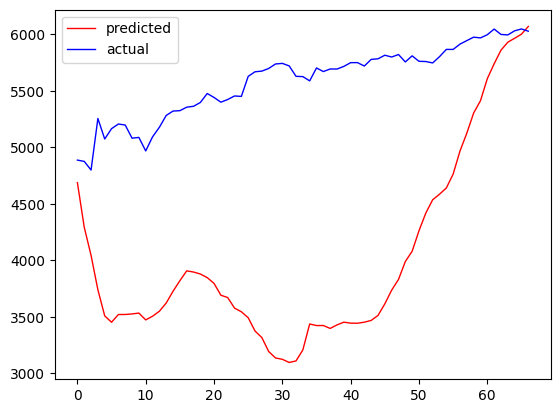

In [125]:
plt.plot(y_pred, c = 'r', lw = 1, label = 'predicted')
plt.plot(y_test, c='b', lw = 1, label = 'actual')

plt.legend()
plt.show()

In [126]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

0.28365839750650157
